# **Compilation of traditional conceptual models: EXP-HYDRO, WB, ABCD, FLEX_A, HBV**

In [28]:
## Import dependent libraries
import os
import logging
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
from datetime import datetime, timedelta

## Import libraries developed by this study
from experiments.hydrodata import DataBasin, load_and_process_data
from experiments.calibrate_test import *

**Please change the following working path to your owns.**

In [29]:
working_path = '.'

## **1. Prepare data**

## **1.1. Load data**

Data in basin #01013500 at huc #01 has been successfully loaded.


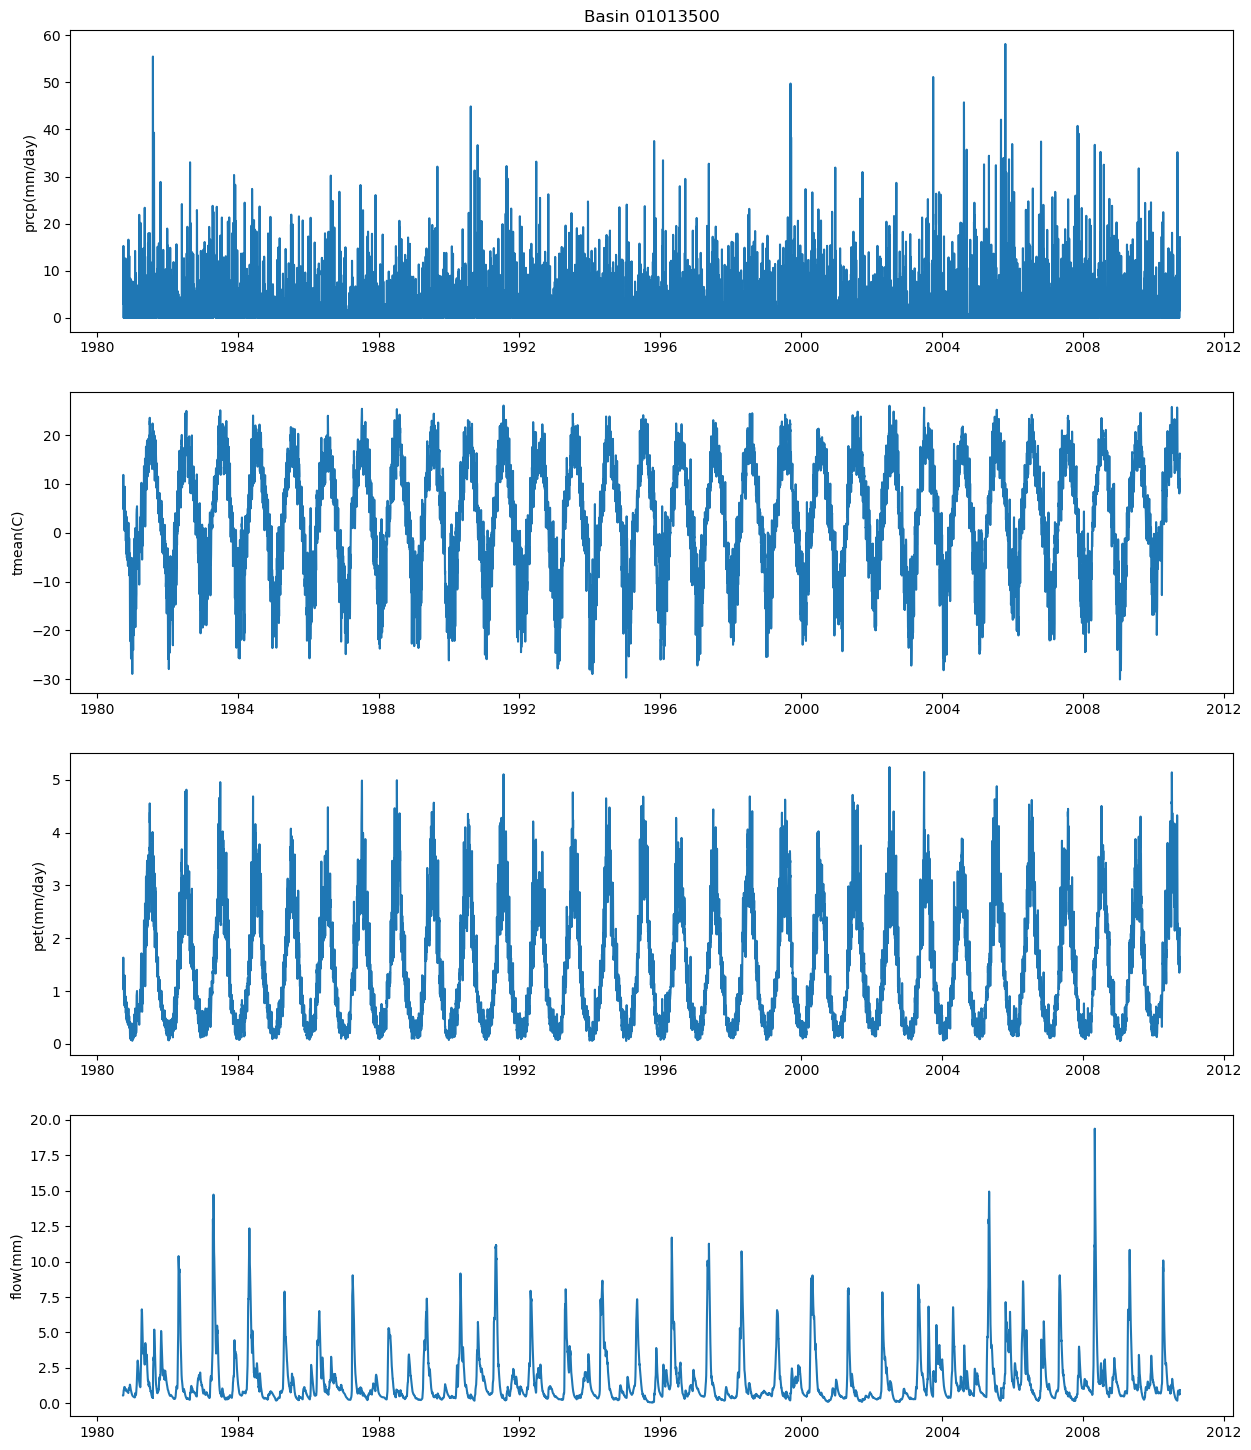

In [30]:
####################
#   Basin set up   #
####################
basin_id = '01013500'

# CAMELS dataset root path
root_path = '../../CAMELS_US/'
dataset_bounds = {'train': {'start': '1980-10-01', 'end': '2000-09-30'},
                  'test' : {'start': '1999-10-01', 'end': '2010-09-30'}}
hydrodata = DataBasin(root_path, basin_id).load_data()

# Plot the data loaded for overview
fig, [ax1, ax2, ax3, ax4] = plt.subplots(nrows=4, ncols=1, sharex='row', figsize=(15, 18))

ax1.plot(hydrodata['prcp(mm/day)'])
ax2.plot(hydrodata['tmean(C)'])
ax3.plot(hydrodata['pet(mm/day)'])
ax4.plot(hydrodata['flow(mm)'])

ax1.set_title(f"Basin {basin_id}")
ax1.set_ylabel("prcp(mm/day)")
ax2.set_ylabel("tmean(C)")
ax3.set_ylabel("pet(mm/day)")
ax4.set_ylabel("flow(mm)")

plt.show()

## **1.2. Generate traning and testing samples**

In [31]:
warmup = 365

# load and process data
train_x, train_y, test_x, test_y, test_set = load_and_process_data(root_path, basin_id, dataset_bounds)
test_set = test_set.iloc[warmup:, :]

# 1. training data
p_train, pet_train, t_train, qobs_train = train_x[:, 0], train_x[:, 1], train_x[:, 2], train_y[:, 0]

# 2. testing data
p_test, pet_test, t_test, qobs_test = test_x[:, 0], test_x[:, 1], test_x[:, 2], test_y[:, 0]

Data in basin #01013500 at huc #01 has been successfully loaded.
The training data set is from 1980-10-01 to 2000-09-30, with a shape of (7305, 4)
The testing data set is from 1999-10-01 to 2010-09-30, with a shape of (4018, 4)
The shape of train_x, train_y, test_x, and test_y are:
(7305, 3), (7305, 1), (4018, 3), and (4018, 1)


## **2. Model building and evaluating**

### **2.1. Utilities for creating, training, and testing the model**

In [32]:
def calibrate_model(model_name, p_train, pet_train, t_train, qobs_train, n_part=10, warmup=365):
    # initialize parameters
    params = [get_params_class(model_name) for j in range(n_part)]

    # initialise the model by loading its climate inputs
    model = get_model(model_name, p_train, pet_train, t_train)

    # calibrate the model
    calperiods_obs = [warmup, len(train_y) - 1]
    calperiods_sim = [warmup, len(train_y) - 1]

    paramsmax = Calibration.pso_maximise(model, params, qobs_train,
                                         ObjectiveFunction.nashsutcliffe,
                                         calperiods_obs, calperiods_sim)
    print('Calibration run NSE value = ', paramsmax.objval)
    return paramsmax

def test_model(model_name, paramsmax, p_test, pet_test, t_test, qobs_test, warmup=365):
    # initialise the model by loading its climate inputs
    model = get_model(model_name, p_test, pet_test, t_test)
    # run the optimised model for test period
    qsim = model.simulate(paramsmax)
    nse = ObjectiveFunction.nashsutcliffe(qobs_test[warmup:], qsim[warmup:])
    print('Test run NSE value = ', nse)
    return qsim[warmup:], qobs_test[warmup:]


In [33]:
# for visualisation
evaluate_set = test_set.loc[:, ['prcp(mm/day)','flow(mm)']]
evaluate_set['flow_obs'] = evaluate_set['flow(mm)']

### **2.2. Train the EXP-HYDRO model**

In [34]:
# calibrate and test
model_name = 'exp-hydro'
paramsmax = calibrate_model(model_name, p_train, pet_train, t_train, qobs_train, n_part=10, warmup=warmup)
qsim, qobs = test_model(model_name, paramsmax, p_test, pet_test, t_test, qobs_test, warmup=warmup)

# add the simulation to evaluation df
evaluate_set['flow_exp-hydro'] = np.clip(qsim, a_min = 0, a_max = None)

Swarm iteration: 1 , Best objfun value: 0.12015589211965261
Swarm iteration: 2 , Best objfun value: 0.4623499438466646
Swarm iteration: 3 , Best objfun value: 0.4623499438466646
Swarm iteration: 4 , Best objfun value: 0.5434649776058591
Swarm iteration: 5 , Best objfun value: 0.5434649776058591
Swarm iteration: 6 , Best objfun value: 0.5434649776058591
Swarm iteration: 7 , Best objfun value: 0.6731736845894829
Swarm iteration: 8 , Best objfun value: 0.6731736845894829
Swarm iteration: 9 , Best objfun value: 0.6731736845894829
Swarm iteration: 10 , Best objfun value: 0.6731736845894829
Swarm iteration: 11 , Best objfun value: 0.6731736845894829
Swarm iteration: 12 , Best objfun value: 0.6731736845894829
Calibration run NSE value =  0.6731736845894829
Test run NSE value =  0.6371139017706542


### **2.3. Train the HBV model**

In [36]:
# calibrate and test
model_name = 'hbv'
paramsmax = calibrate_model(model_name, p_train, pet_train, t_train, qobs_train, n_part=10, warmup=warmup)
qsim, qobs = test_model(model_name, paramsmax, p_test, pet_test, t_test, qobs_test, warmup=warmup)

# add the simulation to evaluation df
evaluate_set['flow_hbv'] = np.clip(qsim, a_min = 0, a_max = None)

Swarm iteration: 1 , Best objfun value: 0.6064721705220215
Swarm iteration: 2 , Best objfun value: 0.6890019085574979
Swarm iteration: 3 , Best objfun value: 0.6890019085574979
Swarm iteration: 4 , Best objfun value: 0.7021825521324098
Swarm iteration: 5 , Best objfun value: 0.7393051947317826
Swarm iteration: 6 , Best objfun value: 0.7393051947317826
Swarm iteration: 7 , Best objfun value: 0.763883397860967
Swarm iteration: 8 , Best objfun value: 0.763883397860967
Swarm iteration: 9 , Best objfun value: 0.79311197996247
Swarm iteration: 10 , Best objfun value: 0.8130574342499335
Swarm iteration: 11 , Best objfun value: 0.8130574342499335
Swarm iteration: 12 , Best objfun value: 0.8174330997806459
Swarm iteration: 13 , Best objfun value: 0.8174330997806459
Swarm iteration: 14 , Best objfun value: 0.8233436591464349
Swarm iteration: 15 , Best objfun value: 0.8233436591464349
Swarm iteration: 16 , Best objfun value: 0.824914097543548
Swarm iteration: 17 , Best objfun value: 0.82491409754

### **2.3. Train the ABCD model**

In [37]:
# calibrate and test
model_name = 'abcd'
paramsmax = calibrate_model(model_name, p_train, pet_train, t_train, qobs_train, n_part=10, warmup=warmup)
qsim, qobs = test_model(model_name, paramsmax, p_test, pet_test, t_test, qobs_test, warmup=warmup)

# add the simulation to evaluation df
evaluate_set['flow_abcd'] = np.clip(qsim, a_min = 0, a_max = None)

Swarm iteration: 1 , Best objfun value: 0.01711061550051307
Swarm iteration: 2 , Best objfun value: 0.024629301957018956
Swarm iteration: 3 , Best objfun value: 0.08352270560688702
Swarm iteration: 4 , Best objfun value: 0.08352270560688702
Swarm iteration: 5 , Best objfun value: 0.14796700134446572
Swarm iteration: 6 , Best objfun value: 0.30265428945313055
Swarm iteration: 7 , Best objfun value: 0.30265428945313055
Swarm iteration: 8 , Best objfun value: 0.48707487510926517
Swarm iteration: 9 , Best objfun value: 0.48707487510926517
Swarm iteration: 10 , Best objfun value: 0.48707487510926517
Swarm iteration: 11 , Best objfun value: 0.6215159414086768
Swarm iteration: 12 , Best objfun value: 0.6215159414086768
Swarm iteration: 13 , Best objfun value: 0.6416604957921461
Swarm iteration: 14 , Best objfun value: 0.6416604957921461
Swarm iteration: 15 , Best objfun value: 0.6439113068757386
Swarm iteration: 16 , Best objfun value: 0.6639342221989014
Swarm iteration: 17 , Best objfun valu

### **2.3. Train the WB model**

In [39]:
# calibrate and test
model_name = 'wbm'
paramsmax = calibrate_model(model_name, p_train, pet_train, t_train, qobs_train, n_part=10, warmup=warmup)
qsim, qobs = test_model(model_name, paramsmax, p_test, pet_test, t_test, qobs_test, warmup=warmup)

# add the simulation to evaluation df
evaluate_set['flow_wb'] = np.clip(qsim, a_min = 0, a_max = None)

Swarm iteration: 1 , Best objfun value: 0.2134204112790561
Swarm iteration: 2 , Best objfun value: 0.25574197202617566
Swarm iteration: 3 , Best objfun value: 0.4577147509820063
Swarm iteration: 4 , Best objfun value: 0.5821560684682433
Swarm iteration: 5 , Best objfun value: 0.5821560684682433
Swarm iteration: 6 , Best objfun value: 0.5821560684682433
Swarm iteration: 7 , Best objfun value: 0.6283260073157964
Swarm iteration: 8 , Best objfun value: 0.6283260073157964
Swarm iteration: 9 , Best objfun value: 0.6814422068104917
Swarm iteration: 10 , Best objfun value: 0.6814422068104917
Swarm iteration: 11 , Best objfun value: 0.6814422068104917
Swarm iteration: 12 , Best objfun value: 0.6814422068104917
Swarm iteration: 13 , Best objfun value: 0.6814422068104917
Swarm iteration: 14 , Best objfun value: 0.7109167860988348
Swarm iteration: 15 , Best objfun value: 0.7109167860988348
Swarm iteration: 16 , Best objfun value: 0.7109167860988348
Swarm iteration: 17 , Best objfun value: 0.71091

### **2.3. Train the FLEX model**

In [40]:
# calibrate and test
model_name = 'flex'
paramsmax = calibrate_model(model_name, p_train, pet_train, t_train, qobs_train, n_part=10, warmup=warmup)
qsim, qobs = test_model(model_name, paramsmax, p_test, pet_test, t_test, qobs_test, warmup=warmup)

# add the simulation to evaluation df
evaluate_set['flow_flex'] = np.clip(qsim, a_min = 0, a_max = None)

Swarm iteration: 1 , Best objfun value: 0.07174681113732329
Swarm iteration: 2 , Best objfun value: 0.12334069935358238
Swarm iteration: 3 , Best objfun value: 0.12334069935358238
Swarm iteration: 4 , Best objfun value: 0.12334069935358238
Swarm iteration: 5 , Best objfun value: 0.130325522463701
Swarm iteration: 6 , Best objfun value: 0.13937763069679054
Swarm iteration: 7 , Best objfun value: 0.1510714733645716
Swarm iteration: 8 , Best objfun value: 0.16090490843261573
Swarm iteration: 9 , Best objfun value: 0.1836202461125207
Swarm iteration: 10 , Best objfun value: 0.19269504630725942
Swarm iteration: 11 , Best objfun value: 0.19269504630725942
Swarm iteration: 12 , Best objfun value: 0.2056252958322693
Swarm iteration: 13 , Best objfun value: 0.2056252958322693
Swarm iteration: 14 , Best objfun value: 0.2056252958322693
Swarm iteration: 15 , Best objfun value: 0.2056252958322693
Swarm iteration: 16 , Best objfun value: 0.21632743047761271
Swarm iteration: 17 , Best objfun value: 

## **3. Visualize the results**

In [41]:
def addYears(date, years):
    result = date + timedelta(366 * years)
    if years > 0:
        while result.year - date.year > years or date.month < result.month or date.day < result.day:
            result += timedelta(-1)
    elif years < 0:
        while result.year - date.year < years or date.month > result.month or date.day > result.day:
            result += timedelta(1)
    return result

"""evaluation_start = datetime.strftime(addYears(datetime.strptime(testing_start, '%Y-%m-%d'), 1), '%Y-%m-%d')
evaluation_end = testing_end"""

"evaluation_start = datetime.strftime(addYears(datetime.strptime(testing_start, '%Y-%m-%d'), 1), '%Y-%m-%d')\nevaluation_end = testing_end"

### **3.1. Calculate Nash Sutcliffe Efficiency of predicted values**

In [43]:
def calc_nse(y_true, y_pred):
    numerator = np.sum((y_pred - y_true) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - numerator / denominator

# We only evaluate the data in the evaluation period
"""date_range = pd.date_range(evaluation_start, evaluation_end) 
evaluate_set = evaluate_set[evaluate_set.index.isin(date_range)]"""

# Calculate respective NSE values
nse_exphydro = calc_nse(evaluate_set['flow_obs'].values, evaluate_set['flow_exp-hydro'].values)
nse_abcd = calc_nse(evaluate_set['flow_obs'].values, evaluate_set['flow_abcd'].values)
nse_hbv = calc_nse(evaluate_set['flow_obs'].values, evaluate_set['flow_hbv'].values)
nse_flex = calc_nse(evaluate_set['flow_obs'].values, evaluate_set['flow_flex'].values)
nse_wb = calc_nse(evaluate_set['flow_obs'].values, evaluate_set['flow_wb'].values)

### **3.2. Plot the results by using the matplotlib library.**

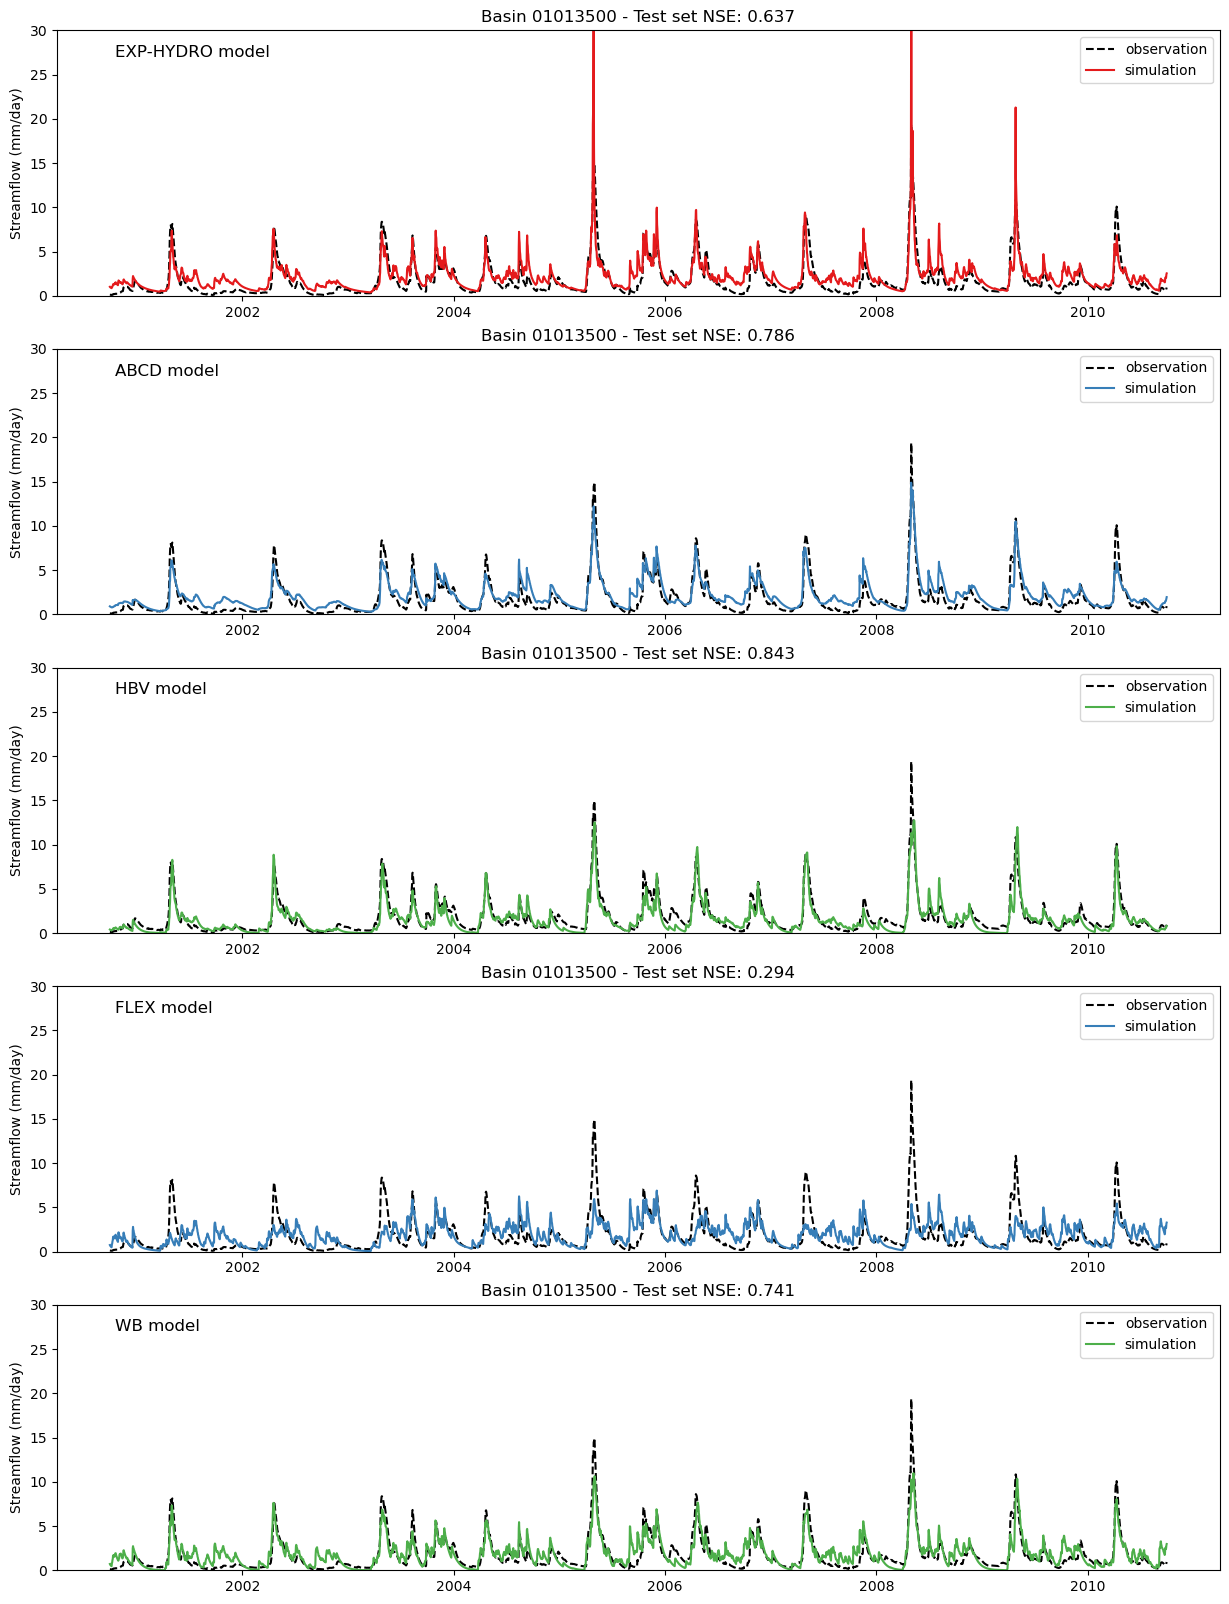

In [46]:
def evaluation_plot(ax, plot_set, plot_name, line_color, nse_values, basin_id):
    ax.plot(plot_set['flow_obs'], label="observation", color='black', ls='--')
    ax.plot(plot_set[plot_name], label="simulation", color=line_color, lw=1.5)
    ax.set_ylim([0, 30])
    ax.set_title(f"Basin {basin_id} - Test set NSE: {nse_values:.3f}")
    ax.set_ylabel("Streamflow (mm/day)")
    ax.legend()

# plot_set = evaluate_set[evaluate_set.index.isin(pd.date_range(testing_start, testing_end))]
plot_set = evaluate_set

fig, [ax1, ax2, ax3, ax4, ax5] = plt.subplots(nrows=5, ncols=1, sharex='row', figsize=(15, 20))

evaluation_plot(ax1, plot_set, 'flow_exp-hydro', '#e41a1c', nse_exphydro, basin_id)
evaluation_plot(ax2, plot_set, 'flow_abcd', '#377eb8', nse_abcd, basin_id)
evaluation_plot(ax3, plot_set, 'flow_hbv', '#4daf4a', nse_hbv, basin_id)
evaluation_plot(ax4, plot_set, 'flow_flex', '#377eb8', nse_flex, basin_id)
evaluation_plot(ax5, plot_set, 'flow_wb', '#4daf4a', nse_wb, basin_id)

ax1.annotate('EXP-HYDRO model', xy=(0.05, 0.9), xycoords='axes fraction', size=12)
ax2.annotate('ABCD model', xy=(0.05, 0.9), xycoords='axes fraction', size=12)
ax3.annotate('HBV model', xy=(0.05, 0.9), xycoords='axes fraction', size=12)
ax4.annotate('FLEX model', xy=(0.05, 0.9), xycoords='axes fraction', size=12)
ax5.annotate('WB model', xy=(0.05, 0.9), xycoords='axes fraction', size=12)
plt.show()